<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/process_control_with_neqsim_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic process control with NeqSim

This tutorial is for process engineers, control engineers, and advanced students who want
to connect thermodynamic process models to feedback control. It develops pressure, level,
cascade, ratio, tuning, and signal-filtering examples and finishes with a controlled
two-stage separation and flash-gas recompression application.

**Prerequisites**

- Basic mass and energy balances
- Familiarity with pressure, level, valves, and compressors
- Introductory Python

**Learning objectives**

1. Build a dynamic NeqSim process from fluids, streams, valves, and separators.
2. Connect transmitters and PI controllers to manipulated equipment.
3. Test setpoint and feed disturbances without hidden notebook state.
4. Implement cascade and ratio supervision around native NeqSim equipment.
5. Compare controller tunings with quantitative performance metrics.
6. Interpret actuator limits, measurement noise, and model-validity constraints.

## Control structure and engineering scope

A feedback loop compares the setpoint $r$ with the measured process variable $y_m$. The
error is

$$
e(t) = r(t) - y_m(t)
$$

A controller converts this error into a manipulated variable $u$, such as valve opening or
compressor speed. NeqSim supplies the thermodynamic state, material inventories, equipment
response, transmitters, controllers, and transient solver. The examples use absolute
pressure in bara, mass flow in kg/h, time in s, and liquid level as a fraction.

These simulations support control-structure studies and teaching. Project design still
requires calibrated valve coefficients, vessel geometry, compressor maps, instrument
dynamics, actuator travel time, relief constraints, and plant-specific disturbance data.

In [1]:
import importlib.metadata
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--quiet",
            "neqsim",
        ],
    )

In [2]:
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import YouTubeVideo, display
from neqsim import jneqsim

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")

NeqSim version: 3.16.0
Python version: 3.12.13


In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "black": "#222222",
}


def source_text(cell_source):
    if isinstance(cell_source, list):
        return "".join(cell_source)
    return cell_source


def integral_absolute_error(time_s, process_value, setpoint):
    time_array = np.asarray(time_s, dtype=float)
    error = np.abs(
        np.asarray(process_value, dtype=float)
        - np.asarray(setpoint, dtype=float)
    )
    return float(np.trapezoid(error, time_array))

## PI control, action, and limits

The practical controllers below use proportional-integral action:

$$
u(t) = u_b + K_c\left[e(t) + \frac{1}{T_i}\int_0^t e(\tau)\,d\tau\right]
$$

Here $u_b$ is the bias, $K_c$ is controller gain, and $T_i$ is integral time in s.
Controller action must match the process gain. Opening a gas outlet valve reduces separator
pressure, while opening a liquid outlet valve reduces level. Incorrect direct/reverse action
drives the controlled variable away from its setpoint.

Manipulated variables are bounded. The examples use valve-opening limits to represent
actuator travel and to expose saturation. In production systems, anti-windup and
bumpless-transfer settings must be checked explicitly.

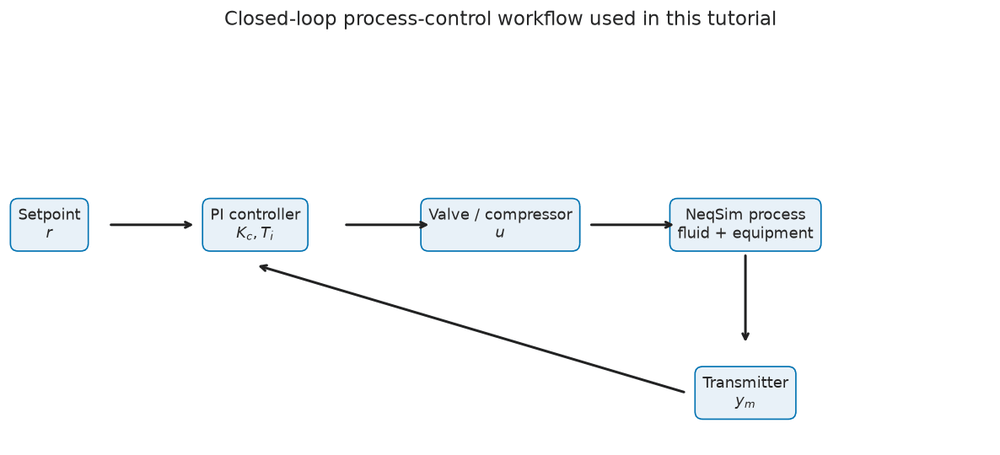

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.axis("off")

blocks = [
    (0.04, 0.55, "Setpoint\n$r$"),
    (0.25, 0.55, "PI controller\n$K_c, T_i$"),
    (0.50, 0.55, "Valve / compressor\n$u$"),
    (0.75, 0.55, "NeqSim process\nfluid + equipment"),
    (0.75, 0.13, "Transmitter\n$y_m$"),
]

for x_pos, y_pos, label in blocks:
    ax.text(
        x_pos,
        y_pos,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox={
            "boxstyle": "round,pad=0.5",
            "facecolor": "#E8F1F8",
            "edgecolor": COLORS["blue"],
        },
    )

arrow_pairs = [
    ((0.10, 0.55), (0.19, 0.55)),
    ((0.34, 0.55), (0.43, 0.55)),
    ((0.59, 0.55), (0.68, 0.55)),
    ((0.75, 0.48), (0.75, 0.25)),
    ((0.69, 0.13), (0.25, 0.45)),
]
for start, end in arrow_pairs:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        xycoords=ax.transAxes,
        arrowprops={"arrowstyle": "->", "color": COLORS["black"], "lw": 1.8},
    )

ax.set_title(
    "Closed-loop process-control workflow used in this tutorial",
    fontsize=14,
    pad=14,
)
plt.tight_layout()
plt.show()

The process model closes the loop: equipment determines the transient state, the
transmitter observes it, and the controller moves an actuator. This architecture also
makes each calculation reusable in a larger `ProcessSystem`.

## Short control primers

The two optional videos introduce feedback terminology and PID behaviour. They are
supplementary learning material; all calculations and conclusions in this notebook are
self-contained.

In [5]:
YouTubeVideo("FEnwYVPDRDE", width=600, height=400)

In [6]:
YouTubeVideo("UR0hOmjaHp0", width=600, height=400)

## Native NeqSim pressure and level control

The first process contains an SRK gas-condensate feed, an inlet valve, a dynamic separator,
and separate gas and liquid outlet valves. `LevelTransmitter` and `PressureTransmitter`
objects measure the vessel. Two `ControllerDeviceBaseClass` objects manipulate the outlet
valves during `ProcessSystem.runTransient()`.

The liquid inventory is represented by vessel geometry and phase volumes. The pressure
response follows the gas inventory, equation of state, inlet flow, and outlet restriction.

In [7]:
def build_controlled_separator(
    pressure_gain=1.0,
    pressure_integral_time_s=50.0,
):
    fluid = jneqsim.thermo.system.SystemSrkEos(298.15, 10.0)
    fluid.addComponent("methane", 0.90)
    fluid.addComponent("ethane", 0.10)
    fluid.addComponent("n-heptane", 1.00)
    fluid.setMixingRule("classic")

    feed = jneqsim.process.equipment.stream.Stream(
        "control feed",
        fluid,
    )
    feed.setFlowRate(50.0, "kg/hr")
    feed.setPressure(10.0, "bara")

    inlet_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "inlet valve",
        feed,
    )
    inlet_valve.setOutletPressure(5.0, "bara")
    inlet_valve.setPercentValveOpening(30.0)
    inlet_valve.setCalculateSteadyState(False)

    separator = jneqsim.process.equipment.separator.Separator(
        "controlled separator",
    )
    separator.addStream(inlet_valve.getOutletStream())
    separator.setSeparatorLength(0.30)
    separator.setInternalDiameter(1.00)
    separator.setLiquidLevel(0.50)
    separator.setCalculateSteadyState(False)

    liquid_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "liquid valve",
        separator.getLiquidOutStream(),
    )
    liquid_valve.setOutletPressure(1.0, "bara")
    liquid_valve.setPercentValveOpening(50.0)
    liquid_valve.setMinimumValveOpening(5.0)
    liquid_valve.setMaximumValveOpening(95.0)
    liquid_valve.setCalculateSteadyState(False)

    gas_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "gas valve",
        separator.getGasOutStream(),
    )
    gas_valve.setOutletPressure(1.0, "bara")
    gas_valve.setPercentValveOpening(50.0)
    gas_valve.setMinimumValveOpening(5.0)
    gas_valve.setMaximumValveOpening(95.0)
    gas_valve.setCalculateSteadyState(False)

    level_tx = jneqsim.process.measurementdevice.LevelTransmitter(
        separator,
    )
    level_tx.setMaximumValue(0.80)
    level_tx.setMinimumValue(0.20)

    pressure_tx = (
        jneqsim.process.measurementdevice.PressureTransmitter(
            separator.getGasOutStream(),
        )
    )
    pressure_tx.setUnit("bara")
    pressure_tx.setMaximumValue(10.0)
    pressure_tx.setMinimumValue(1.0)

    level_controller = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    level_controller.setReverseActing(False)
    level_controller.setTransmitter(level_tx)
    level_controller.setControllerSetPoint(0.45)
    level_controller.setControllerParameters(1.0, 200.0, 0.0)

    pressure_controller = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    pressure_controller.setReverseActing(False)
    pressure_controller.setTransmitter(pressure_tx)
    pressure_controller.setControllerSetPoint(5.0)
    pressure_controller.setControllerParameters(
        pressure_gain,
        pressure_integral_time_s,
        0.0,
    )

    liquid_valve.setController(level_controller)
    gas_valve.setController(pressure_controller)

    process = jneqsim.process.processmodel.ProcessSystem()
    equipment = [
        feed,
        inlet_valve,
        separator,
        liquid_valve,
        gas_valve,
        level_tx,
        pressure_tx,
    ]
    for item in equipment:
        process.add(item)

    process.run()
    process.setTimeStep(5.0)
    return {
        "process": process,
        "feed": feed,
        "separator": separator,
        "liquid_valve": liquid_valve,
        "gas_valve": gas_valve,
        "level_tx": level_tx,
        "pressure_tx": pressure_tx,
        "level_controller": level_controller,
        "pressure_controller": pressure_controller,
    }

In [8]:
separator_case = build_controlled_separator()
separator_records = []

for step in range(140):
    if step == 20:
        separator_case["pressure_controller"].setControllerSetPoint(4.5)
    if step == 80:
        separator_case["feed"].setFlowRate(65.0, "kg/hr")
        separator_case["level_controller"].setControllerSetPoint(0.55)

    separator_case["process"].runTransient()
    separator_records.append(
        {
            "time_s": float(separator_case["process"].getTime()),
            "level_fraction": float(
                separator_case["level_tx"].getMeasuredValue()
            ),
            "level_setpoint": float(
                separator_case["level_controller"].getControllerSetPoint()
            ),
            "pressure_bara": float(
                separator_case["pressure_tx"].getMeasuredValue()
            ),
            "pressure_setpoint_bara": float(
                separator_case[
                    "pressure_controller"
                ].getControllerSetPoint()
            ),
            "liquid_valve_percent": float(
                separator_case[
                    "liquid_valve"
                ].getPercentValveOpening()
            ),
            "gas_valve_percent": float(
                separator_case["gas_valve"].getPercentValveOpening()
            ),
        }
    )

separator_results = pd.DataFrame(separator_records)
display(separator_results.iloc[[0, 19, 20, 79, 80, -1]])

     time_s  level_fraction  ...  liquid_valve_percent  gas_valve_percent
0       5.0        0.500000  ...             58.541667          50.000000
19    100.0        0.498779  ...             62.245687          49.853396
20    105.0        0.498535  ...             62.407227          55.954088
79    400.0        0.492188  ...             72.536214          61.173949
80    405.0        0.492188  ...             55.628662          61.025776
139   700.0        0.494141  ...             41.859436          54.875181

[6 rows x 7 columns]


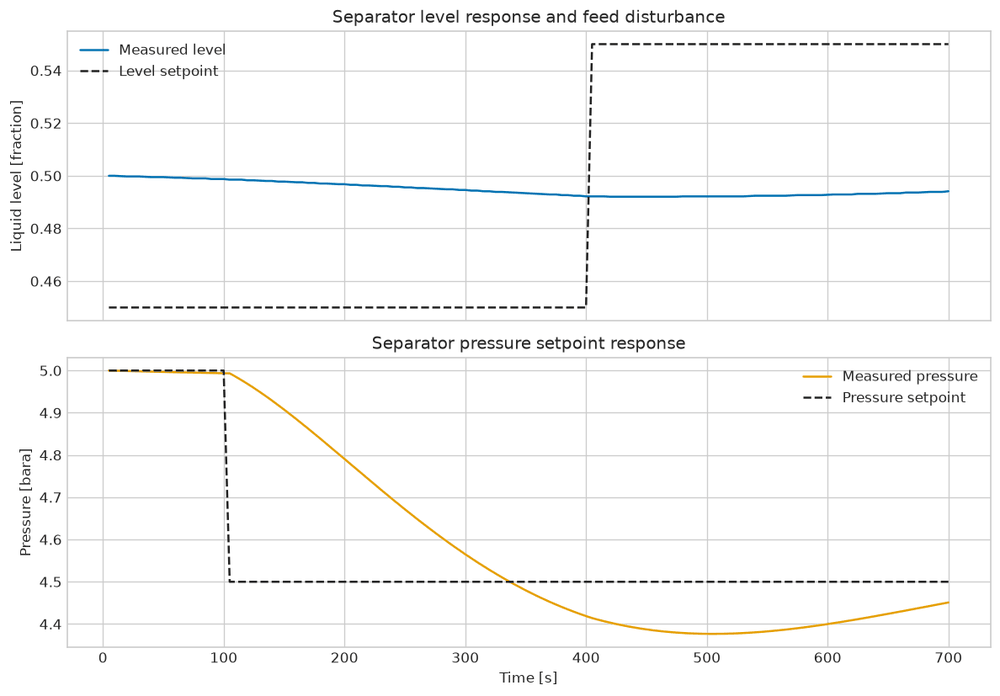

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    separator_results["time_s"],
    separator_results["level_fraction"],
    color=COLORS["blue"],
    label="Measured level",
)
axes[0].plot(
    separator_results["time_s"],
    separator_results["level_setpoint"],
    color=COLORS["black"],
    linestyle="--",
    label="Level setpoint",
)
axes[0].set_ylabel("Liquid level [fraction]")
axes[0].set_title("Separator level response and feed disturbance")
axes[0].legend(loc="best")

axes[1].plot(
    separator_results["time_s"],
    separator_results["pressure_bara"],
    color=COLORS["orange"],
    label="Measured pressure",
)
axes[1].plot(
    separator_results["time_s"],
    separator_results["pressure_setpoint_bara"],
    color=COLORS["black"],
    linestyle="--",
    label="Pressure setpoint",
)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Pressure [bara]")
axes[1].set_title("Separator pressure setpoint response")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

The pressure loop tracks the lower setpoint by opening the gas outlet. The later feed-flow
and level-setpoint change tests interaction between material inventory and both outlet
valves. Level and pressure remain finite and bounded, but the response time depends on the
deliberately small teaching vessel and simplified valve data.

## Final application: two-stage separation and flash-gas recompression

The end-to-end application connects two dynamic separators through an interstage valve.
Gas flashed in the second stage is recompressed to the first-stage pressure. Two level
transmitters control the inlet and interstage valves, while a pressure transmitter changes
compressor speed through a generated compressor chart.

This structure demonstrates how NeqSim represents:

- the SRK fluid and phase equilibrium;
- named streams between unit operations;
- separator holdup and transient inventories;
- valve and compressor actuators;
- measurement and controller objects;
- steady initialization followed by transient integration.

In [10]:
def build_two_stage_separation():
    fluid = jneqsim.thermo.system.SystemSrkEos(313.15, 50.0)
    fluid.addComponent("nitrogen", 0.10)
    fluid.addComponent("methane", 0.90)
    fluid.addComponent("ethane", 0.10)
    fluid.addComponent("n-heptane", 0.40)
    fluid.setMixingRule("classic")

    feed = jneqsim.process.equipment.stream.Stream(
        "two-stage feed",
        fluid,
    )
    feed.setFlowRate(200.0, "kg/hr")
    feed.setTemperature(40.0, "C")
    feed.setPressure(50.0, "bara")
    feed.setCalculateSteadyState(False)

    valve_one = jneqsim.process.equipment.valve.ThrottlingValve(
        "stage-one inlet valve",
        feed,
    )
    valve_one.setOutletPressure(40.0, "bara")
    valve_one.setPercentValveOpening(50.0)
    valve_one.setCalculateSteadyState(False)

    separator_one = jneqsim.process.equipment.separator.Separator(
        "stage-one separator",
    )
    separator_one.addStream(valve_one.getOutletStream())
    separator_one.setSeparatorLength(0.30)
    separator_one.setInternalDiameter(1.00)
    separator_one.setLiquidLevel(0.50)
    separator_one.setCalculateSteadyState(False)

    valve_two = jneqsim.process.equipment.valve.ThrottlingValve(
        "interstage liquid valve",
        separator_one.getLiquidOutStream(),
    )
    valve_two.setOutletPressure(5.0, "bara")
    valve_two.setPercentValveOpening(50.0)
    valve_two.setCalculateSteadyState(False)

    separator_two = jneqsim.process.equipment.separator.Separator(
        "stage-two separator",
    )
    separator_two.addStream(valve_two.getOutletStream())
    separator_two.setSeparatorLength(0.10)
    separator_two.setInternalDiameter(0.40)
    separator_two.setLiquidLevel(0.20)
    separator_two.setCalculateSteadyState(False)

    product_valve = (
        jneqsim.process.equipment.valve.ThrottlingValve(
            "stage-two product valve",
            separator_two.getLiquidOutStream(),
        )
    )
    product_valve.setOutletPressure(1.0, "bara")
    product_valve.setPercentValveOpening(50.0)
    product_valve.setCalculateSteadyState(False)

    recompressor = jneqsim.process.equipment.compressor.Compressor(
        "flash-gas recompressor",
        separator_two.getGasOutStream(),
    )
    recompressor.setOutletPressure(40.0, "bara")
    recompressor.setCalculateSteadyState(False)

    level_one = jneqsim.process.measurementdevice.LevelTransmitter(
        separator_one,
    )
    level_one.setMaximumValue(0.80)
    level_one.setMinimumValue(0.20)

    level_two = jneqsim.process.measurementdevice.LevelTransmitter(
        separator_two,
    )
    level_two.setMaximumValue(0.30)
    level_two.setMinimumValue(0.10)

    controller_one = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    controller_one.setReverseActing(False)
    controller_one.setTransmitter(level_one)
    controller_one.setControllerSetPoint(0.50)
    controller_one.setControllerParameters(0.01, 200.0, 0.0)

    controller_two = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    controller_two.setReverseActing(False)
    controller_two.setTransmitter(level_two)
    controller_two.setControllerSetPoint(0.20)
    controller_two.setControllerParameters(0.01, 200.0, 0.0)

    valve_two.setController(controller_one)
    product_valve.setController(controller_two)

    pressure_tx = (
        jneqsim.process.measurementdevice.PressureTransmitter(
            recompressor.getOutletStream(),
        )
    )
    pressure_tx.setUnit("bara")

    speed_controller = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    speed_controller.setReverseActing(True)
    speed_controller.setTransmitter(pressure_tx)
    speed_controller.setControllerSetPoint(40.0)
    speed_controller.setControllerParameters(0.2, 500.0, 0.0)
    recompressor.setController(speed_controller)

    export_mixer = jneqsim.process.equipment.mixer.Mixer(
        "export gas mixer",
    )
    export_mixer.addStream(separator_one.getGasOutStream())
    export_mixer.addStream(recompressor.getOutletStream())

    process = jneqsim.process.processmodel.ProcessSystem()
    equipment = [
        feed,
        valve_one,
        separator_one,
        valve_two,
        separator_two,
        product_valve,
        recompressor,
        export_mixer,
        level_one,
        level_two,
        pressure_tx,
    ]
    for item in equipment:
        process.add(item)

    process.run()
    chart_generator = (
        jneqsim.process.equipment.compressor.CompressorChartGenerator(
            recompressor,
        )
    )
    compressor_chart = chart_generator.generateCompressorChart("normal")
    recompressor.setCompressorChart(compressor_chart)
    recompressor.getCompressorChart().setUseCompressorChart(True)
    process.run()
    process.setTimeStep(1.0)

    return {
        "process": process,
        "feed": feed,
        "valve_one": valve_one,
        "separator_one": separator_one,
        "separator_two": separator_two,
        "recompressor": recompressor,
        "export_mixer": export_mixer,
    }

In [11]:
two_stage_case = build_two_stage_separation()
two_stage_records = []

for step in range(120):
    if step < 35:
        inlet_valve_target_percent = 50.0
    elif step < 80:
        inlet_valve_target_percent = 35.0
    else:
        inlet_valve_target_percent = 65.0

    two_stage_case["valve_one"].setPercentValveOpening(
        inlet_valve_target_percent
    )

    two_stage_case["process"].runTransient()
    two_stage_records.append(
        {
            "time_s": float(two_stage_case["process"].getTime()),
            "inlet_valve_target_percent": (
                inlet_valve_target_percent
            ),
            "feed_kg_per_h": float(
                two_stage_case[
                    "valve_one"
                ].getOutletStream().getFlowRate("kg/hr")
            ),
            "stage_one_level": float(
                two_stage_case["separator_one"].getLiquidLevel()
            ),
            "stage_two_level": float(
                two_stage_case["separator_two"].getLiquidLevel()
            ),
            "compressor_speed_rpm": float(
                two_stage_case["recompressor"].getSpeed()
            ),
            "compressor_power_kw": float(
                two_stage_case["recompressor"].getPower("kW")
            ),
        }
    )

two_stage_results = pd.DataFrame(two_stage_records)
display(two_stage_results.iloc[[0, 34, 35, 79, 80, -1]])

     time_s  ...  compressor_power_kw
0       1.0  ...             0.511331
34     35.0  ...             0.494614
35     36.0  ...             0.495203
79     80.0  ...             0.481155
80     81.0  ...             0.481355
119   120.0  ...             0.475886

[6 rows x 7 columns]


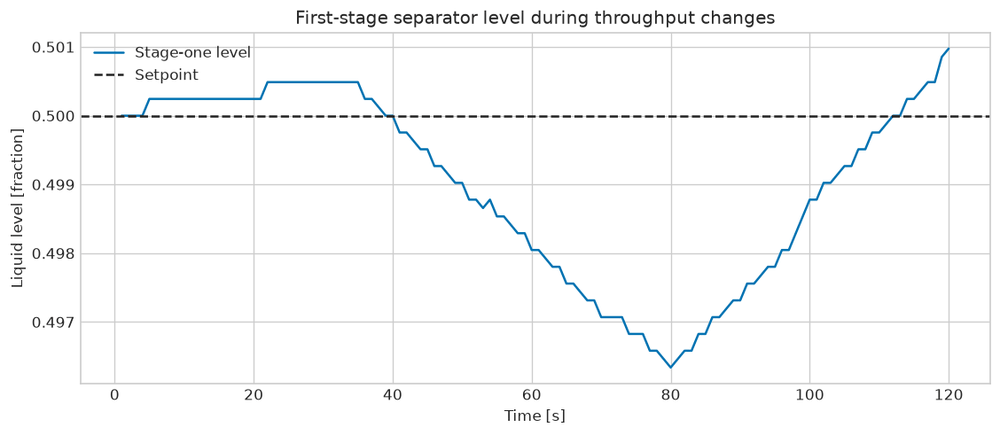

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(
    two_stage_results["time_s"],
    two_stage_results["stage_one_level"],
    color=COLORS["blue"],
    label="Stage-one level",
)
ax.axhline(
    0.50,
    color=COLORS["black"],
    linestyle="--",
    label="Setpoint",
)
ax.set(
    title="First-stage separator level during throughput changes",
    xlabel="Time [s]",
    ylabel="Liquid level [fraction]",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

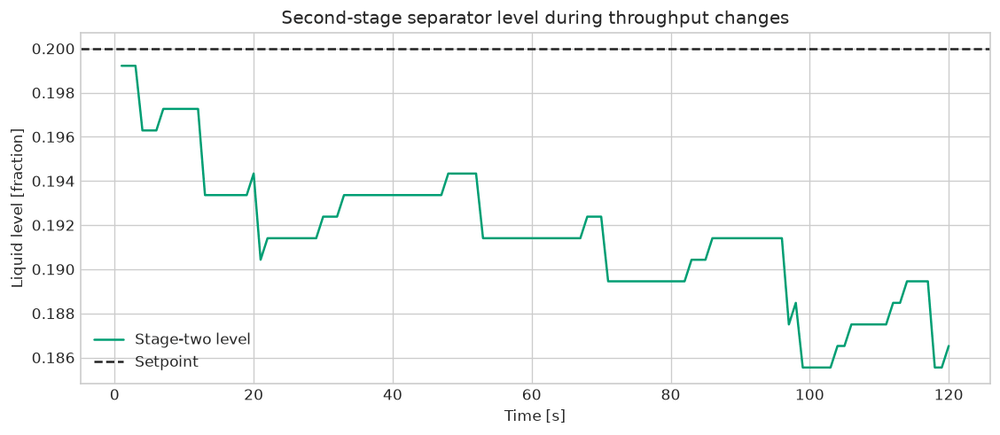

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(
    two_stage_results["time_s"],
    two_stage_results["stage_two_level"],
    color=COLORS["green"],
    label="Stage-two level",
)
ax.axhline(
    0.20,
    color=COLORS["black"],
    linestyle="--",
    label="Setpoint",
)
ax.set(
    title="Second-stage separator level during throughput changes",
    xlabel="Time [s]",
    ylabel="Liquid level [fraction]",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

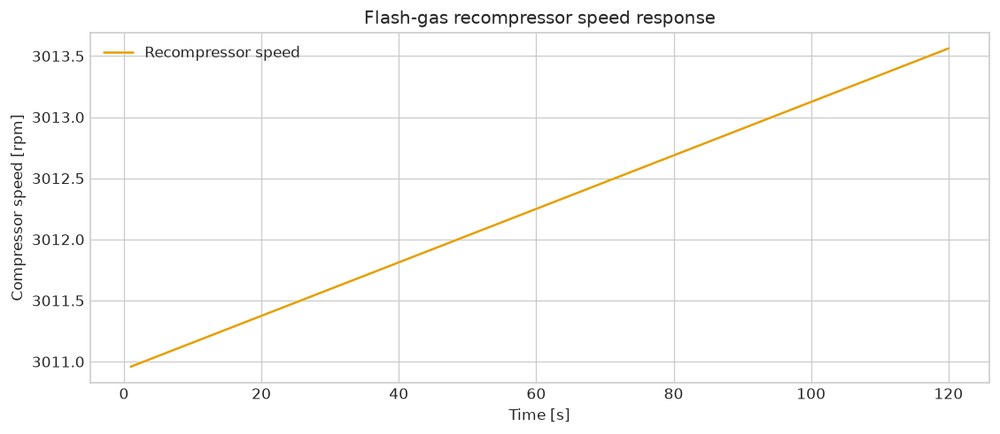

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(
    two_stage_results["time_s"],
    two_stage_results["compressor_speed_rpm"],
    color=COLORS["orange"],
    label="Recompressor speed",
)
ax.set(
    title="Flash-gas recompressor speed response",
    xlabel="Time [s]",
    ylabel="Compressor speed [rpm]",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The separate level and compressor-speed plots provide the key operating views needed to
diagnose this multi-loop system. Both separator inventories remain near their setpoints
through the throughput sequence, while the compressor controller adjusts speed to support
pressure control. The generated map is illustrative; vendor maps and surge/choke limits are
required for equipment decisions.

## Cascade control

Cascade control uses a slow primary loop to set the target of a faster secondary loop. The
primary separator-pressure controller changes the gas-flow setpoint; the secondary native
NeqSim controller changes gas-valve opening. A simplified supervisory update is

$$
r_f(k+1) = \operatorname{clip}\left[r_f(k) + K_o(P_k-r_P)\right]
$$

where $r_f$ is the inner flow setpoint in m$^3$/h, $K_o$ is the outer gain, $P_k$ is
measured pressure in bara, and $r_P$ is the pressure setpoint. Clipping represents an
operator-defined feasible flow range.

In [15]:
def build_cascade_control():
    fluid = jneqsim.thermo.system.SystemSrkEos(298.15, 10.0)
    fluid.addComponent("methane", 1.0)
    fluid.setMixingRule("classic")

    feed = jneqsim.process.equipment.stream.Stream(
        "cascade feed",
        fluid,
    )
    feed.setFlowRate(50.0, "kg/hr")
    feed.setPressure(10.0, "bara")

    inlet_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "cascade inlet valve",
        feed,
    )
    inlet_valve.setOutletPressure(5.0, "bara")
    inlet_valve.setCalculateSteadyState(False)

    separator = jneqsim.process.equipment.separator.Separator(
        "cascade separator",
    )
    separator.addStream(inlet_valve.getOutletStream())
    separator.setSeparatorLength(0.30)
    separator.setInternalDiameter(1.00)
    separator.setCalculateSteadyState(False)

    gas_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "cascade gas valve",
        separator.getGasOutStream(),
    )
    gas_valve.setOutletPressure(1.0, "bara")
    gas_valve.setPercentValveOpening(50.0)
    gas_valve.setCalculateSteadyState(False)

    flow_tx = (
        jneqsim.process.measurementdevice.VolumeFlowTransmitter(
            gas_valve.getOutletStream(),
        )
    )
    flow_tx.setUnit("m3/hr")
    flow_tx.setMaximumValue(1000.0)
    flow_tx.setMinimumValue(0.0)

    flow_controller = (
        jneqsim.process.controllerdevice.ControllerDeviceBaseClass()
    )
    flow_controller.setReverseActing(True)
    flow_controller.setTransmitter(flow_tx)
    flow_controller.setControllerSetPoint(150.0)
    flow_controller.setControllerParameters(0.2, 80.0, 0.0)
    gas_valve.setController(flow_controller)

    pressure_tx = (
        jneqsim.process.measurementdevice.PressureTransmitter(
            separator.getGasOutStream(),
        )
    )
    pressure_tx.setUnit("bara")

    process = jneqsim.process.processmodel.ProcessSystem()
    equipment = [
        feed,
        inlet_valve,
        separator,
        gas_valve,
        flow_tx,
        pressure_tx,
    ]
    for item in equipment:
        process.add(item)

    process.run()
    process.setTimeStep(2.0)
    return {
        "process": process,
        "flow_controller": flow_controller,
        "flow_tx": flow_tx,
        "pressure_tx": pressure_tx,
        "gas_valve": gas_valve,
    }

In [16]:
cascade_case = build_cascade_control()
cascade_records = []
pressure_setpoint = 5.0
flow_setpoint = float(
    cascade_case["flow_controller"].getControllerSetPoint()
)

for step in range(90):
    if step == 35:
        pressure_setpoint = 4.7

    measured_pressure = float(
        cascade_case["pressure_tx"].getMeasuredValue()
    )
    pressure_error = measured_pressure - pressure_setpoint
    flow_setpoint += 1.5 * pressure_error
    flow_setpoint = float(np.clip(flow_setpoint, 20.0, 400.0))
    cascade_case["flow_controller"].setControllerSetPoint(
        flow_setpoint
    )
    cascade_case["process"].runTransient()

    cascade_records.append(
        {
            "time_s": float(cascade_case["process"].getTime()),
            "pressure_bara": float(
                cascade_case["pressure_tx"].getMeasuredValue()
            ),
            "pressure_setpoint_bara": pressure_setpoint,
            "flow_m3_per_h": float(
                cascade_case["flow_tx"].getMeasuredValue()
            ),
            "flow_setpoint_m3_per_h": flow_setpoint,
            "gas_valve_percent": float(
                cascade_case["gas_valve"].getPercentValveOpening()
            ),
        }
    )

cascade_results = pd.DataFrame(cascade_records)
display(cascade_results.iloc[[0, 34, 35, 60, -1]])

    time_s  pressure_bara  ...  flow_setpoint_m3_per_h  gas_valve_percent
0      2.0       2.501104  ...              150.000000          51.516261
34    70.0       4.343996  ...               80.698464          51.098591
35    72.0       4.365570  ...               80.164457          51.087436
60   122.0       4.692788  ...               74.541297          50.940511
89   180.0       4.825449  ...               77.540766          50.981890

[5 rows x 6 columns]


## Ratio control

Ratio control maintains a secondary flow $q_B$ relative to a reference flow $q_A$:

$$
R = \frac{q_B}{q_A}
$$

The example measures both NeqSim streams and moves the trim-valve opening toward the
opening implied by the desired ratio. A reference-flow disturbance tests whether the ratio
returns to $R=0.5$. Real applications should use compatible standard or actual volumetric
bases and account for pressure and temperature compensation.

In [17]:
def build_ratio_control():
    fluid = jneqsim.thermo.system.SystemSrkEos(298.15, 20.0)
    fluid.addComponent("methane", 1.0)
    fluid.setMixingRule("classic")

    reference = jneqsim.process.equipment.stream.Stream(
        "reference stream",
        fluid,
    )
    reference.setFlowRate(100.0, "kg/hr")
    reference.setPressure(20.0, "bara")

    trim = jneqsim.process.equipment.stream.Stream(
        "trim stream",
        fluid.clone(),
    )
    trim.setFlowRate(50.0, "kg/hr")
    trim.setPressure(20.0, "bara")

    trim_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        "ratio trim valve",
        trim,
    )
    trim_valve.setOutletPressure(15.0, "bara")
    trim_valve.setPercentValveOpening(50.0)
    trim_valve.setCalculateSteadyState(False)

    mixer = jneqsim.process.equipment.mixer.Mixer("ratio mixer")
    mixer.addStream(reference)
    mixer.addStream(trim_valve.getOutletStream())

    reference_tx = (
        jneqsim.process.measurementdevice.VolumeFlowTransmitter(
            reference,
        )
    )
    reference_tx.setUnit("m3/hr")

    trim_tx = (
        jneqsim.process.measurementdevice.VolumeFlowTransmitter(
            trim_valve.getOutletStream(),
        )
    )
    trim_tx.setUnit("m3/hr")

    process = jneqsim.process.processmodel.ProcessSystem()
    equipment = [
        reference,
        trim,
        trim_valve,
        mixer,
        reference_tx,
        trim_tx,
    ]
    for item in equipment:
        process.add(item)

    process.run()
    process.setTimeStep(2.0)
    return {
        "process": process,
        "reference": reference,
        "trim_valve": trim_valve,
        "reference_tx": reference_tx,
        "trim_tx": trim_tx,
    }

In [18]:
ratio_case = build_ratio_control()
ratio_records = []
ratio_setpoint = 0.50

for step in range(90):
    if step == 40:
        ratio_case["reference"].setFlowRate(70.0, "kg/hr")

    reference_flow = float(
        ratio_case["reference_tx"].getMeasuredValue()
    )
    trim_flow = float(ratio_case["trim_tx"].getMeasuredValue())
    measured_ratio = trim_flow / reference_flow

    opening = float(
        ratio_case["trim_valve"].getPercentValveOpening()
    )
    desired_opening = opening * ratio_setpoint / measured_ratio
    opening += 0.25 * (desired_opening - opening)
    opening = float(np.clip(opening, 10.0, 90.0))
    ratio_case["trim_valve"].setPercentValveOpening(opening)
    ratio_case["process"].runTransient()

    ratio_records.append(
        {
            "time_s": float(ratio_case["process"].getTime()),
            "ratio": measured_ratio,
            "ratio_setpoint": ratio_setpoint,
            "reference_flow_m3_per_h": reference_flow,
            "trim_flow_m3_per_h": trim_flow,
            "trim_valve_percent": opening,
        }
    )

ratio_results = pd.DataFrame(ratio_records)
display(ratio_results.iloc[[0, 39, 40, 60, -1]])

    time_s     ratio  ...  trim_flow_m3_per_h  trim_valve_percent
0      2.0  0.666728  ...            4.977585           46.874137
39    80.0  0.500002  ...            3.732862           37.496675
40    82.0  0.714288  ...            3.732858           34.684402
60   122.0  0.500680  ...            2.616543           26.274339
89   180.0  0.500000  ...            2.612993           26.247591

[5 rows x 6 columns]


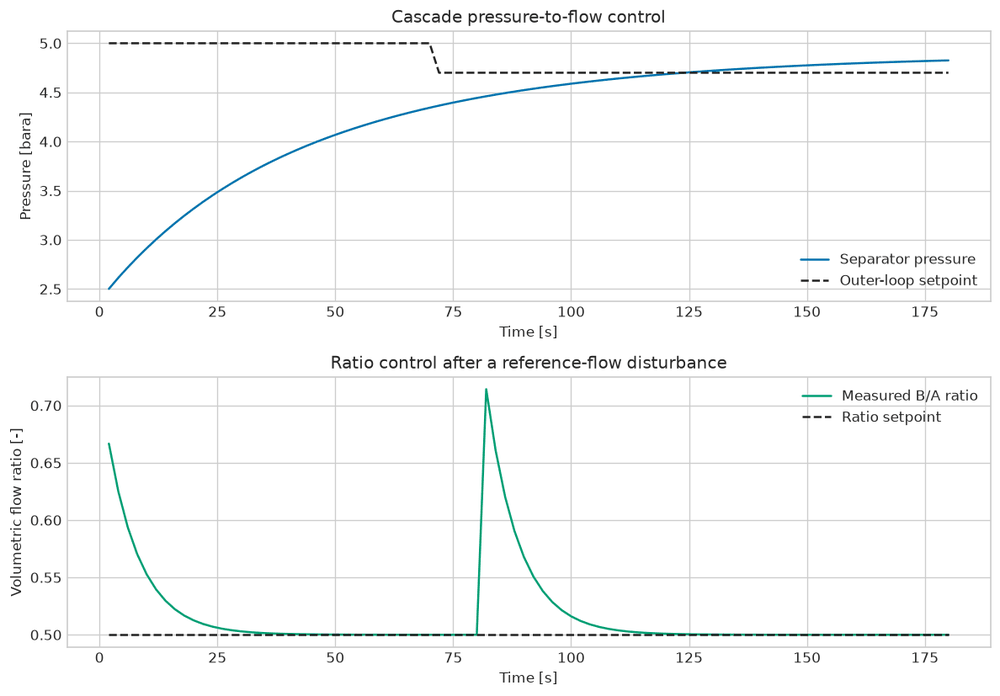

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

axes[0].plot(
    cascade_results["time_s"],
    cascade_results["pressure_bara"],
    color=COLORS["blue"],
    label="Separator pressure",
)
axes[0].plot(
    cascade_results["time_s"],
    cascade_results["pressure_setpoint_bara"],
    color=COLORS["black"],
    linestyle="--",
    label="Outer-loop setpoint",
)
axes[0].set(
    title="Cascade pressure-to-flow control",
    xlabel="Time [s]",
    ylabel="Pressure [bara]",
)
axes[0].legend(loc="best")

axes[1].plot(
    ratio_results["time_s"],
    ratio_results["ratio"],
    color=COLORS["green"],
    label="Measured B/A ratio",
)
axes[1].plot(
    ratio_results["time_s"],
    ratio_results["ratio_setpoint"],
    color=COLORS["black"],
    linestyle="--",
    label="Ratio setpoint",
)
axes[1].set(
    title="Ratio control after a reference-flow disturbance",
    xlabel="Time [s]",
    ylabel="Volumetric flow ratio [-]",
)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

The cascade result shows the outer loop moving the inner flow target until separator
pressure approaches its new setpoint. The ratio regulator restores the target after the
reference stream is reduced. Both supervisors include explicit bounds and should be
retuned if equipment, flow basis, or sample time changes.

## Step-response tuning

Controller comparisons need an objective metric. The integral of absolute error is

$$
IAE = \int_0^{t_f}\left|r(t)-y(t)\right|\,dt
$$

A lower IAE is useful only if the response remains stable and actuator motion is
acceptable. The next calculation runs two independent NeqSim separator cases from clean
initial states, changes pressure from 5.0 to 4.5 bara, and compares conservative and
responsive PI settings.

In [20]:
def run_pressure_step(proportional_gain, integral_time_s):
    case = build_controlled_separator(
        pressure_gain=proportional_gain,
        pressure_integral_time_s=integral_time_s,
    )
    records = []

    for step in range(100):
        setpoint = 5.0 if step < 20 else 4.5
        case["pressure_controller"].setControllerSetPoint(setpoint)
        case["process"].runTransient()
        records.append(
            {
                "time_s": float(case["process"].getTime()),
                "pressure_bara": float(
                    case["pressure_tx"].getMeasuredValue()
                ),
                "setpoint_bara": setpoint,
                "gas_valve_percent": float(
                    case["gas_valve"].getPercentValveOpening()
                ),
            }
        )

    results = pd.DataFrame(records)
    results["label"] = (
        f"Kc={proportional_gain:.1f}, "
        f"Ti={integral_time_s:.0f} s"
    )
    return results


conservative_results = run_pressure_step(0.5, 300.0)
responsive_results = run_pressure_step(2.0, 150.0)
tuning_results = pd.concat(
    [conservative_results, responsive_results],
    ignore_index=True,
)

tuning_summary = []
for label, group in tuning_results.groupby("label", sort=False):
    tuning_summary.append(
        {
            "tuning": label,
            "IAE_bara_s": integral_absolute_error(
                group["time_s"],
                group["pressure_bara"],
                group["setpoint_bara"],
            ),
            "minimum_pressure_bara": group.loc[
                group["time_s"] >= 105.0,
                "pressure_bara",
            ].min(),
            "final_pressure_bara": group["pressure_bara"].iloc[-1],
            "maximum_valve_opening_percent": group[
                "gas_valve_percent"
            ].max(),
        }
    )

tuning_summary = pd.DataFrame(tuning_summary)
display(tuning_summary)

             tuning  ...  maximum_valve_opening_percent
0  Kc=0.5, Ti=300 s  ...                      54.046786
1  Kc=2.0, Ti=150 s  ...                      61.372563

[2 rows x 5 columns]


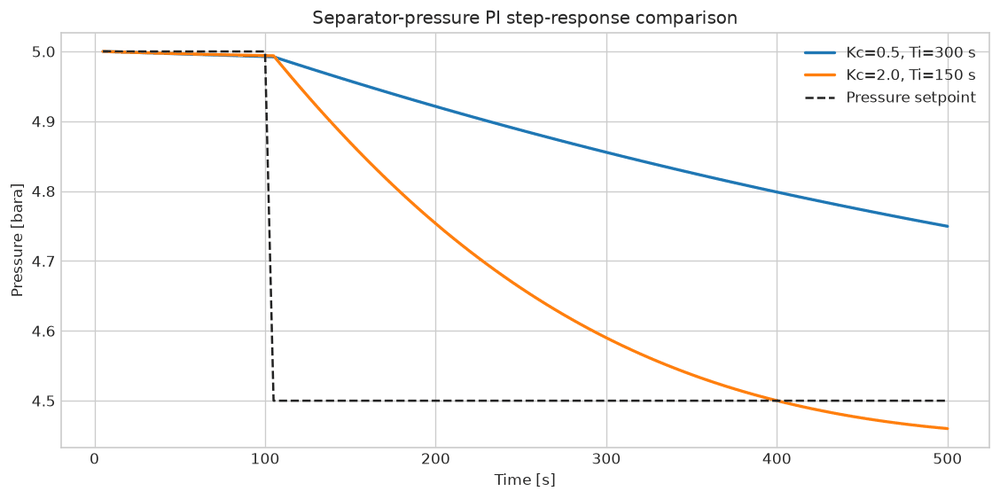

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))

for label, group in tuning_results.groupby("label", sort=False):
    ax.plot(
        group["time_s"],
        group["pressure_bara"],
        linewidth=2.0,
        label=label,
    )

ax.plot(
    conservative_results["time_s"],
    conservative_results["setpoint_bara"],
    color=COLORS["black"],
    linestyle="--",
    label="Pressure setpoint",
)
ax.set(
    title="Separator-pressure PI step-response comparison",
    xlabel="Time [s]",
    ylabel="Pressure [bara]",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The responsive tuning reduces integrated error at the cost of more aggressive actuator
movement and a larger undershoot. Selection therefore depends on pressure constraints,
valve travel, process interaction, and acceptable settling time—not IAE alone.

## Measurement noise and filtering

A pressure transmitter can include measurement noise. Filtering reduces high-frequency
variation but introduces delay, so the filter window must be short relative to the process
time constant. The moving average below is deliberately transparent; project systems may
use validated low-pass or state-estimation filters.

In [22]:
noise_fluid = jneqsim.thermo.system.SystemSrkEos(298.15, 10.0)
noise_fluid.addComponent("methane", 1.0)
noise_fluid.setMixingRule("classic")

noise_feed = jneqsim.process.equipment.stream.Stream(
    "noise feed",
    noise_fluid,
)
noise_feed.setFlowRate(100.0, "kg/hr")
noise_feed.setPressure(10.0, "bara")

noise_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "noise valve",
    noise_feed,
)
noise_valve.setOutletPressure(1.0, "bara")
noise_valve.setCalculateSteadyState(False)

noise_tx = jneqsim.process.measurementdevice.PressureTransmitter(
    noise_valve.getOutletStream(),
)
noise_tx.setUnit("bara")
noise_tx.setMaximumValue(10.0)
noise_tx.setMinimumValue(0.0)
noise_tx.setNoiseStdDev(0.05)

noise_process = jneqsim.process.processmodel.ProcessSystem()
for item in [noise_feed, noise_valve, noise_tx]:
    noise_process.add(item)
noise_process.run()
noise_process.setTimeStep(1.0)

noise_records = []
measured_values = []
for step in range(100):
    noise_process.runTransient()
    measured_value = float(noise_tx.getMeasuredValue())
    measured_values.append(measured_value)
    filtered_value = float(np.mean(measured_values[-7:]))
    noise_records.append(
        {
            "time_s": float(noise_process.getTime()),
            "measured_pressure_bara": measured_value,
            "filtered_pressure_bara": filtered_value,
        }
    )

noise_results = pd.DataFrame(noise_records)
display(noise_results.describe().loc[["mean", "std", "min", "max"]])

          time_s  measured_pressure_bara  filtered_pressure_bara
mean   50.500000                0.999001                1.000469
std    29.011492                0.046408                0.018602
min     1.000000                0.895058                0.957979
max   100.000000                1.117933                1.049402


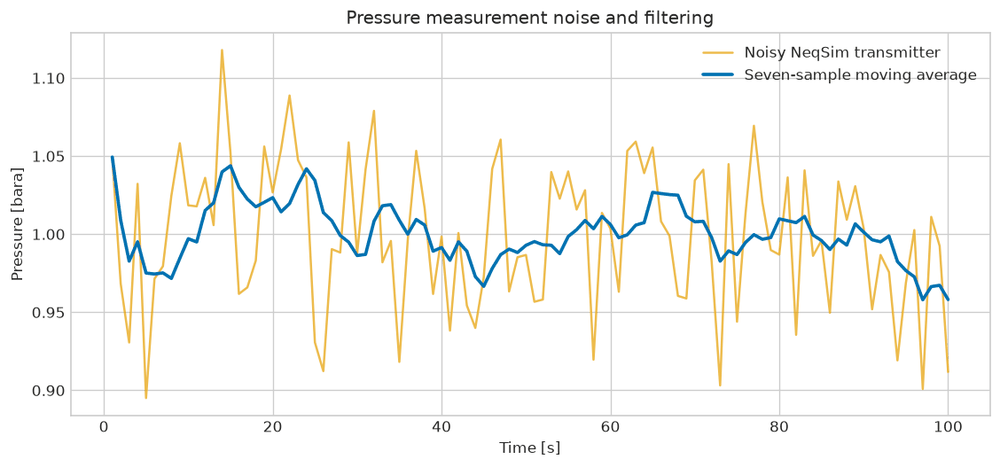

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(
    noise_results["time_s"],
    noise_results["measured_pressure_bara"],
    color=COLORS["orange"],
    alpha=0.70,
    label="Noisy NeqSim transmitter",
)
ax.plot(
    noise_results["time_s"],
    noise_results["filtered_pressure_bara"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Seven-sample moving average",
)
ax.set(
    title="Pressure measurement noise and filtering",
    xlabel="Time [s]",
    ylabel="Pressure [bara]",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The moving average visibly reduces transmitter variation. A controller sees the filtered
signal later than the raw signal, so excessive smoothing can degrade disturbance rejection
or destabilize a fast loop.

## Verification and engineering checks

The checks below confirm finite states, physical level bounds, actuator bounds, setpoint
recovery, improved IAE for the responsive tuning, and noise reduction. They are regression
checks for this teaching case, not universal controller-acceptance criteria.

In [24]:
checks = {
    "separator results finite": np.isfinite(
        separator_results.select_dtypes("number")
    ).all().all(),
    "separator level physical": separator_results[
        "level_fraction"
    ].between(0.0, 1.0).all(),
    "separator pressure positive": (
        separator_results["pressure_bara"] > 0.0
    ).all(),
    "separator valves bounded": (
        separator_results[
            ["liquid_valve_percent", "gas_valve_percent"]
        ]
        .ge(0.0)
        .all()
        .all()
        and separator_results[
            ["liquid_valve_percent", "gas_valve_percent"]
        ]
        .le(100.0)
        .all()
        .all()
    ),
    "two-stage levels physical": (
        two_stage_results[
            ["stage_one_level", "stage_two_level"]
        ]
        .ge(0.0)
        .all()
        .all()
        and two_stage_results[
            ["stage_one_level", "stage_two_level"]
        ]
        .le(1.0)
        .all()
        .all()
    ),
    "compressor speed positive": (
        two_stage_results["compressor_speed_rpm"] > 0.0
    ).all(),
    "compressor power finite": np.isfinite(
        two_stage_results["compressor_power_kw"]
    ).all(),
    "inlet-valve throughput steps applied": (
        abs(two_stage_results["feed_kg_per_h"].iloc[35] - 140.0)
        < 1.0e-6
        and abs(
            two_stage_results["feed_kg_per_h"].iloc[80] - 260.0
        )
        < 1.0e-6
    ),
    "cascade pressure approaches target": abs(
        cascade_results["pressure_bara"].iloc[-1]
        - cascade_results["pressure_setpoint_bara"].iloc[-1]
    )
    < 0.15,
    "cascade flow target bounded": cascade_results[
        "flow_setpoint_m3_per_h"
    ].between(20.0, 400.0).all(),
    "ratio recovers after disturbance": abs(
        ratio_results["ratio"].iloc[-1] - 0.50
    )
    < 0.01,
    "ratio valve bounded": ratio_results[
        "trim_valve_percent"
    ].between(10.0, 90.0).all(),
    "responsive tuning lowers IAE": (
        tuning_summary["IAE_bara_s"].iloc[1]
        < tuning_summary["IAE_bara_s"].iloc[0]
    ),
    "filtered signal is smoother": (
        noise_results["filtered_pressure_bara"].iloc[10:].std()
        < noise_results["measured_pressure_bara"].iloc[10:].std()
    ),
}

for check_name, passed in checks.items():
    assert bool(passed), check_name

check_table = pd.DataFrame(
    {
        "check": list(checks),
        "status": ["PASS" for _ in checks],
    }
)
display(check_table)
print(f"All {len(checks)} engineering checks passed.")

                                   check status
0               separator results finite   PASS
1               separator level physical   PASS
2            separator pressure positive   PASS
3               separator valves bounded   PASS
4              two-stage levels physical   PASS
5              compressor speed positive   PASS
6                compressor power finite   PASS
7   inlet-valve throughput steps applied   PASS
8     cascade pressure approaches target   PASS
9            cascade flow target bounded   PASS
10      ratio recovers after disturbance   PASS
11                   ratio valve bounded   PASS
12          responsive tuning lowers IAE   PASS
13           filtered signal is smoother   PASS
All 14 engineering checks passed.


## Dynamic-model assumptions and validity limits

NeqSim integrates transient material and energy inventories with a finite time step. A
first-order approximation is often useful for interpreting a single response:

$$
\tau\frac{dy}{dt} + y = K u
$$

Here $\tau$ is the process time constant in s and $K$ is process gain. Real separator and
compressor systems can be nonlinear, interacting, and constrained. Results are sensitive
to vessel dimensions, initial phase inventory, valve sizing, compressor maps, sample time,
controller action, saturation, and thermodynamic model selection.

Important limitations of this tutorial include illustrative equipment dimensions, generated
rather than vendor compressor curves, no valve-stiction model, no network communication
delay, no safety-instrumented functions, and no actuator-failure scenarios.

## Troubleshooting

- **The loop moves away from the setpoint:** check direct/reverse action and process gain.
- **A valve saturates:** verify pressure boundaries, valve sizing, flow basis, and controller
  output limits before increasing gain.
- **A dynamic run fails after a disturbance:** reduce time step, apply a smaller disturbance,
  and confirm no stream has negative flow or invalid phase inventory.
- **A compressor leaves its map:** use measured vendor curves and enforce surge, choke, and
  speed constraints.
- **A ratio loop is biased:** ensure both transmitters use compatible standard or actual
  volumetric conditions.
- **Noise destabilizes the loop:** compare transmitter sample time, filter delay, and
  controller integral time.

## Summary

This notebook used current NeqSim process APIs to build dynamic pressure and level loops,
a two-stage separation and recompression system, cascade supervision, ratio control,
independent tuning comparisons, and measurement filtering. The key reusable pattern is:

fluid and streams → equipment and inventories → transmitters → controllers → transient run
→ engineering metrics and constraints.

## Further exercises

1. Add gas-valve travel time and compare pressure overshoot.
2. Replace the generated compressor chart with a vendor map and plot surge margin.
3. Tune the level loops for a fivefold larger separator while preserving response quality.
4. Add a feed-temperature disturbance and quantify pressure-level interaction.
5. Implement anti-windup for the cascade supervisor.
6. Compare a first-order filter with the moving average at equal noise attenuation.

## References

- NeqSim documentation: https://equinor.github.io/neqsim/
- NeqSim Python package: https://pypi.org/project/neqsim/
- NeqSim process equipment API:
  https://equinor.github.io/neqsimhome/neqsim_process_api.html
- Seborg, Edgar, Mellichamp, and Doyle, *Process Dynamics and Control*, 4th edition.
- Åström and Hägglund, *PID Controllers: Theory, Design, and Tuning*.